#In this notebook I will compare Multi-layer Perceptron Models with Convolutional Neural Networks in completing the same task of multi-class image classification.

*   The notebook consists of three parts in each of which I implemented one recently learned machine learning topic. My own words as well as conclusion can be found at the end of each section.
*   For the model creation I used FashionMnist image dataset and PyTorch library

* For the data visualization I used MatPlotLib



# MLP model

In [ ]:
#device initialization
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [ ]:
#downloading the dataset
from torchvision.datasets import FashionMNIST
from torchvision.transforms.v2 import Compose, PILToTensor, ToDtype, Normalize

fashion_transform = Compose([
    PILToTensor(),
    ToDtype(torch.float32, scale=True),
    Normalize((0.5,), (0.25,))
])
fashion = FashionMNIST(root='fashion', download=True, train=True, transform=fashion_transform)

fashion_names = fashion.classes

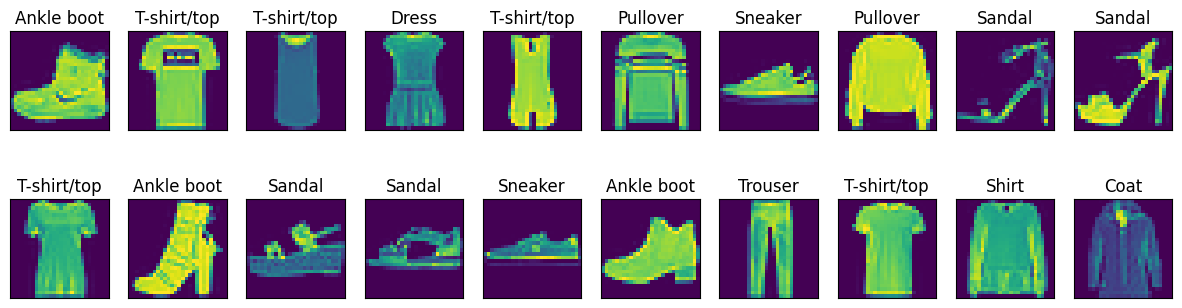

In [ ]:
#showing the dataset items
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(fashion[i][0].permute(1, 2, 0) * 0.25 + 0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(fashion_names[fashion[i][1]])

plt.show()

In [ ]:
#splitting into the train and validation datasets
from torch.utils.data import random_split

train_set, valid_set = random_split(fashion, (0.95, 0.05))

In [ ]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#building MLP model
from torch import nn
from torchsummary import summary

model = nn.Sequential(
    nn.Flatten(1),
    nn.Linear(in_features=784, out_features=512),
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=10),
    nn.Sigmoid()
).to(device)

summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                   [-1, 64]          32,832
              ReLU-5                   [-1, 64]               0
            Linear-6                   [-1, 10]             650
           Sigmoid-7                   [-1, 10]               0
Total params: 435,402
Trainable params: 435,402
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 1.66
Estimated Total Size (MB): 1.68
----------------------------------------------------------------


In [ ]:
#initializing dataloaders, optimizer(stochastic gradient descent) and criterion(cross-entropy loss)
from torch.utils.data import DataLoader

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(train_set, batch_size=8)
valid_loader = DataLoader(valid_set, batch_size=8)

In [ ]:
#creating a trainer, evaluator and defining metrics
from ignite.engine import create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss

trainer = create_supervised_trainer(model, optimizer, criterion, device)

metrics = {
    "accuracy": Accuracy(),
    "loss": Loss(criterion)
}

train_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)
valid_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)

In [ ]:
#creating log reporting for each epoch
from ignite.engine import Events

current_epoch = 0
train_hist = []
valid_hist = []

def compute_epoch_results(engine):
    train_evaluator.run(train_loader)
    valid_evaluator.run(valid_loader)

trainer.add_event_handler(Events.EPOCH_COMPLETED, compute_epoch_results)

def log_epoch_results(engine, label=""):
    if label == "Train":
        global current_epoch
        current_epoch += 1
        print(f'Epoch {current_epoch}:')

    result = ', '.join([f"{m} = {v}" for m, v in engine.state.metrics.items()])
    print(f"{label} Res:", result)
    if label == "Train":
        train_hist.append((float(result.split(', ')[0].split(' = ')[1]), float(result.split(', ')[1].split(' = ')[1])))
    else:
        valid_hist.append((float(result.split(', ')[0].split(' = ')[1]), float(result.split(', ')[1].split(' = ')[1])))

train_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Train")

valid_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Valid")

In [ ]:
from ignite.handlers.param_scheduler import ReduceLROnPlateauScheduler

#scheduler for reducing the learning rate when needed
scheduler = ReduceLROnPlateauScheduler(
    optimizer,
    metric_name="loss",
    factor=0.5,
    patience=1,
    threshold=0.1
)

def print_lr(): #reporting learning rate
    for param_group in optimizer.param_groups:
        print(f"Optimizer learning rate = {param_group['lr']}")

valid_evaluator.add_event_handler(Events.COMPLETED, scheduler)
valid_evaluator.add_event_handler(Events.COMPLETED, print_lr)

In [ ]:
#plotting training and validation history
import matplotlib.pyplot as plt
import numpy as np

def show_hist(train_hist, valid_hist):
    train_hist = np.array(train_hist)
    valid_hist = np.array(valid_hist)
    plt.figure(figsize=(16,4))
    plt.subplot(1, 2, 1)
    plt.plot(np.arange(1, len(train_hist) + 1), train_hist[:, 1], label='train')
    plt.plot(np.arange(1, len(valid_hist) + 1), valid_hist[:, 1], label='validation')
    plt.legend()
    plt.ylabel('Loss')
    plt.xlabel('Epoch')

    plt.figure(figsize=(16,4))
    plt.subplot(1, 2, 2)
    plt.plot(np.arange(1, len(train_hist) + 1), train_hist[:, 0], label='train')
    plt.plot(np.arange(1, len(valid_hist) + 1), valid_hist[:, 0], label='validation')
    plt.legend()
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')

    plt.grid()

    plt.show()

In [ ]:
trainer.run(train_loader, 5)

Epoch 1:
Train Res: accuracy = 0.6454210526315789, loss = 1.790854577850877
Valid Res: accuracy = 0.643, loss = 1.79248876953125
Optimizer learning rate = 0.001
Epoch 2:
Train Res: accuracy = 0.6356315789473684, loss = 1.7075024671052632
Valid Res: accuracy = 0.6386666666666667, loss = 1.7062732747395832
Optimizer learning rate = 0.001
Epoch 3:
Train Res: accuracy = 0.6359473684210526, loss = 1.6789747807017543
Valid Res: accuracy = 0.6403333333333333, loss = 1.6772913411458332
Optimizer learning rate = 0.0005
Epoch 4:
Train Res: accuracy = 0.6365263157894737, loss = 1.6701602247807017
Valid Res: accuracy = 0.6406666666666667, loss = 1.6681785481770834
Optimizer learning rate = 0.0005
Epoch 5:
Train Res: accuracy = 0.6366666666666667, loss = 1.6634952028508772
Valid Res: accuracy = 0.6423333333333333, loss = 1.66126220703125
Optimizer learning rate = 0.00025


State:
	iteration: 35625
	epoch: 5
	epoch_length: 7125
	max_epochs: 5
	output: 1.7084712982177734
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

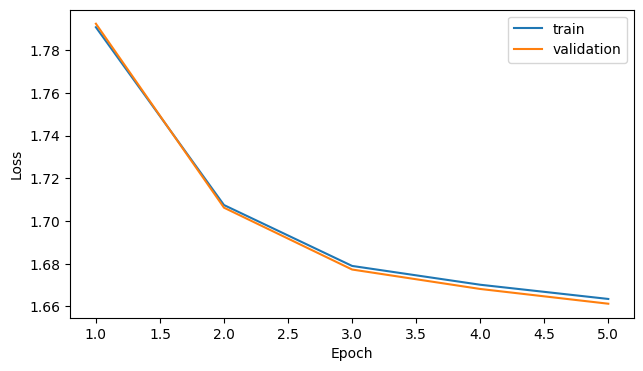

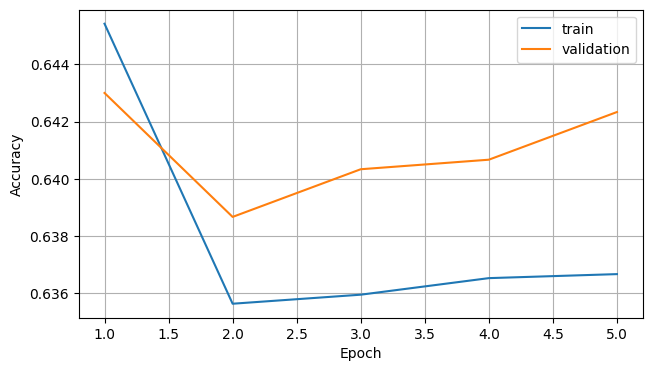

In [ ]:
show_hist(train_hist, valid_hist)

Although accuracy and loss have been improving with epochs, their absolute values were not impressive(acccuracy of 60% and loss of 1.66 is not a good score for this task). Conclusion: MLP models are not greatly suited for this kinds of problems.

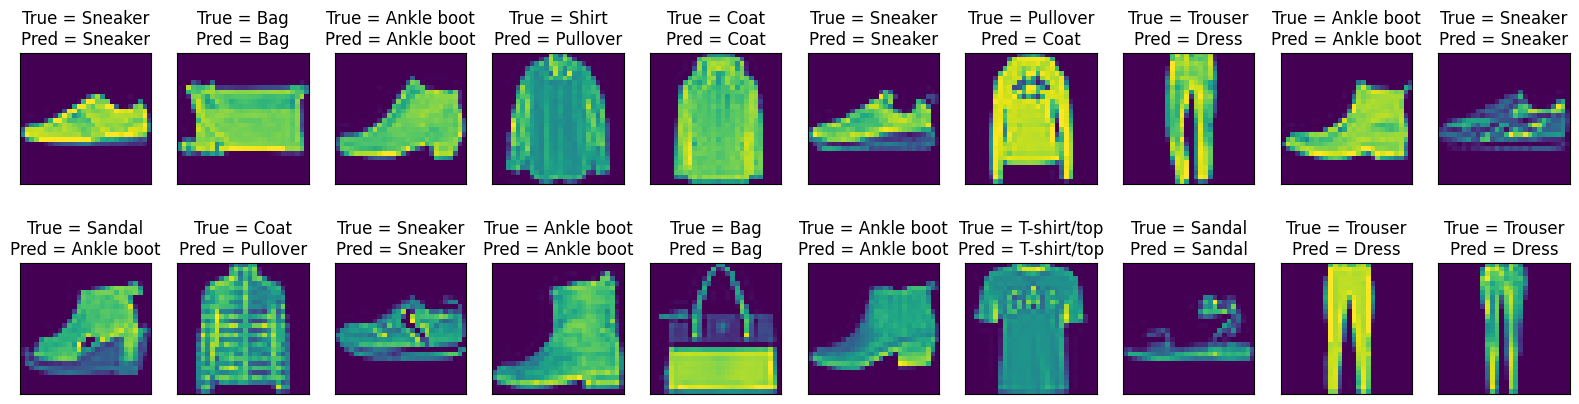

In [ ]:
from random import randrange #picking random examples from the dataset to test the model

model.eval()
plt.figure(figsize=(20,5))

for i in range(20):
    x, y_true = valid_set[randrange(0, len(valid_set))]
    y_pred = torch.argmax(model(x.to(device)))
    plt.subplot(2, 10, i + 1)
    plt.imshow(x.permute(1, 2, 0) * 0.25 + 0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'True = {fashion_names[y_true]}\nPred = {fashion_names[y_pred]}')

plt.show()

As we can see, the model make mistakes quite frequently

# Solving the same problem with a convolutional neural network model

In [ ]:
#building new model, this time its architecture is convolutional
model = nn.Sequential(
    nn.Conv2d(1, 16, 4),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(16, 64, 4),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(64, 256, 4),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Flatten(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 25, 25]             272
       BatchNorm2d-2           [-1, 16, 25, 25]              32
              ReLU-3           [-1, 16, 25, 25]               0
           Dropout-4           [-1, 16, 25, 25]               0
         MaxPool2d-5           [-1, 16, 12, 12]               0
            Conv2d-6             [-1, 64, 9, 9]          16,448
       BatchNorm2d-7             [-1, 64, 9, 9]             128
              ReLU-8             [-1, 64, 9, 9]               0
           Dropout-9             [-1, 64, 9, 9]               0
        MaxPool2d-10             [-1, 64, 4, 4]               0
           Conv2d-11            [-1, 256, 1, 1]         262,400
      BatchNorm2d-12            [-1, 256, 1, 1]             512
             ReLU-13            [-1, 256, 1, 1]               0
          Dropout-14            [-1, 25

In [ ]:
#initializing optimizer, criterion, dataloaders, metrics, etc.
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(train_set, batch_size=8)
valid_loader = DataLoader(valid_set, batch_size=8)

trainer = create_supervised_trainer(model, optimizer, criterion, device)

metrics = {
    "accuracy": Accuracy(),
    "loss": Loss(criterion)
}
current_epoch = 0
train_hist = []
valid_hist = []

train_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)
valid_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)

trainer.add_event_handler(Events.EPOCH_COMPLETED, compute_epoch_results)
train_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Train")
valid_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Valid")

In [ ]:
trainer.run(train_loader, 5)

Epoch 1:
Train Res: accuracy = 0.8768771929824561, loss = 0.35794102933114036
Valid Res: accuracy = 0.8696666666666667, loss = 0.37346915690104165
Epoch 2:
Train Res: accuracy = 0.8899122807017544, loss = 0.3105680167214912
Valid Res: accuracy = 0.8843333333333333, loss = 0.3283580525716146
Epoch 3:
Train Res: accuracy = 0.8957894736842106, loss = 0.28535308730811404
Valid Res: accuracy = 0.8886666666666667, loss = 0.3083912556966146
Epoch 4:
Train Res: accuracy = 0.9000350877192983, loss = 0.2724510005482456
Valid Res: accuracy = 0.8846666666666667, loss = 0.3072678426106771
Epoch 5:
Train Res: accuracy = 0.9064561403508772, loss = 0.2571977967379386
Valid Res: accuracy = 0.8876666666666667, loss = 0.2988101806640625


State:
	iteration: 35625
	epoch: 5
	epoch_length: 7125
	max_epochs: 5
	output: 0.4373621344566345
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

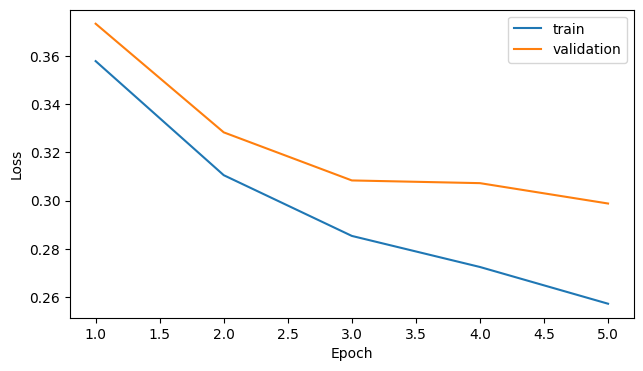

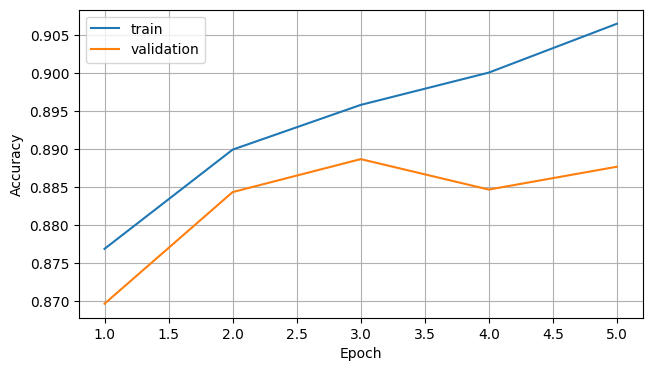

In [ ]:
show_hist(train_hist, valid_hist)

Similarly to MLP model training, the loss did not decrease greatly with epochs, but this time its value was around 10 times less on average. Accuracy increased by 0.3 and was 0.9 on validation. I can conclude that convolutional neural networks are better suited for image classification problems.

# Adding data augmentations

In [ ]:
#downloading augmented datasets
from torchvision.transforms.v2 import RandomHorizontalFlip, RandomVerticalFlip

fashion_hor_flip = Compose([
    RandomHorizontalFlip(1),
    PILToTensor(),
    ToDtype(torch.float32, scale=True),
    Normalize((0.5, ), (0.25, ))
])

fashion_hor_flip = FashionMNIST(root='fashion_hor_flipped', download=True, train=True, transform=fashion_hor_flip)
fashion_ver_flip = Compose([
    RandomVerticalFlip(1),
    PILToTensor(),
    ToDtype(torch.float32, scale=True),
    Normalize((0.5, ), (0.25, ))
])

fashion_ver_flip = FashionMNIST(root='fashion_ver_flipped', download=True, train=True, transform=fashion_ver_flip)

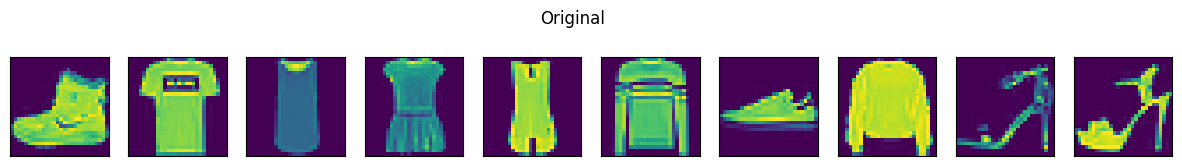

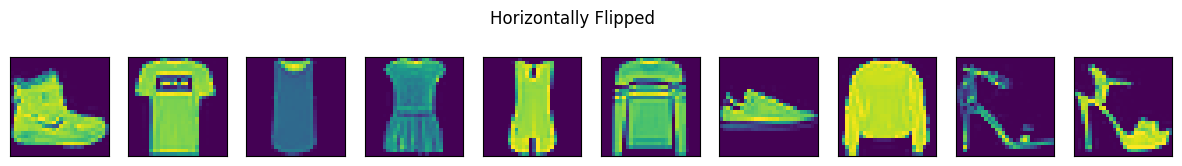

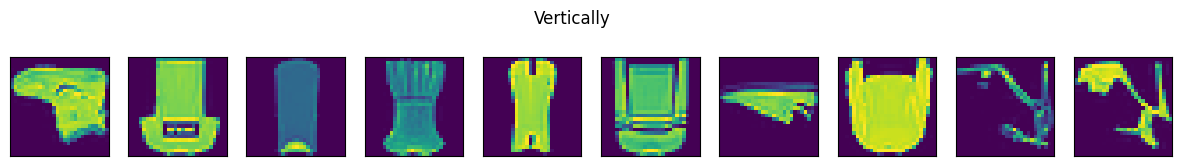

In [ ]:
#displaying each dataset
plt.figure(figsize=(15,2))
plt.suptitle("Original")

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(fashion[i][0].permute(1, 2, 0) * 0.25 + 0.5)
    plt.xticks([])
    plt.yticks([])

plt.figure(figsize=(15,2))
plt.suptitle("Horizontally Flipped")

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(fashion_hor_flip[i][0].permute(1, 2, 0) * 0.25 + 0.5)
    plt.xticks([])
    plt.yticks([])

plt.figure(figsize=(15,2))
plt.suptitle("Vertically Flipped")

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(fashion_ver_flip[i][0].permute(1, 2, 0) * 0.25 + 0.5)
    plt.xticks([])
    plt.yticks([])

plt.show()

In [ ]:
#uniting three datasets
import torch.utils.data as data_utils

indices1 = torch.arange(0,len(fashion)//3)
indices2 = torch.arange(len(fashion)//3, 2*len(fashion)//3)
indices3 = torch.arange(2*len(fashion)//3, len(fashion))
fashion_hor_flip = data_utils.Subset(fashion_hor_flip, indices2)
fashion_ver_flip = data_utils.Subset(fashion_ver_flip, indices3)

train_set, valid_set = random_split(data_utils.Subset(fashion, indices)+fashion_hor_flip+fashion_ver_flip, (0.95, 0.05))

In [ ]:
#initializing optimizer, criterion, dataloaders, metrics, etc.
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(train_set, batch_size=8)
valid_loader = DataLoader(valid_set, batch_size=8)

trainer = create_supervised_trainer(model, optimizer, criterion, device)
metrics = {
    "accuracy": Accuracy(),
    "loss": Loss(criterion)
}
current_epoch = 0
train_hist = []
valid_hist = []

train_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)
valid_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)

trainer.add_event_handler(Events.EPOCH_COMPLETED, compute_epoch_results)
train_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Train")
valid_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Valid")

In [ ]:
trainer.run(train_loader, 5)

Epoch 1:
Train Res: accuracy = 0.8582771299032323, loss = 0.3993206422134753
Valid Res: accuracy = 0.8469781397342477, loss = 0.4301623864793185
Epoch 2:
Train Res: accuracy = 0.8760291430762638, loss = 0.35479980700042857
Valid Res: accuracy = 0.858979854264895, loss = 0.3903130745100863
Epoch 3:
Train Res: accuracy = 0.8765253874089279, loss = 0.34187875267154266
Valid Res: accuracy = 0.8576939562794685, loss = 0.38617924421680777
Epoch 4:
Train Res: accuracy = 0.8838111564748607, loss = 0.32231902060823764
Valid Res: accuracy = 0.864123446206601, loss = 0.37526308166791683
Epoch 5:
Train Res: accuracy = 0.8932172422349041, loss = 0.3001979954971466
Valid Res: accuracy = 0.8709815687955422, loss = 0.3571346984418533


State:
	iteration: 27710
	epoch: 5
	epoch_length: 5542
	max_epochs: 5
	output: 0.39257314801216125
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

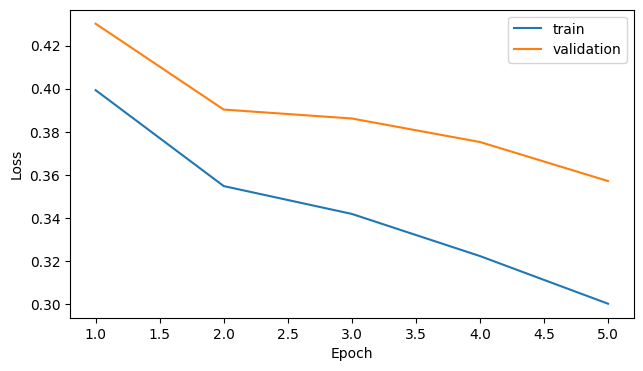

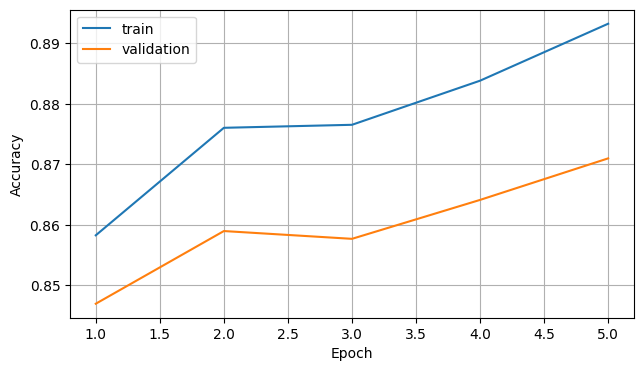

In [ ]:
show_hist(train_hist, valid_hist)

In this section I applied horizontal and vertical flip transformations to third part of the dataset each(2/3 in total) and the another third was unchanged. Model performance was not significantly affected by this image tranformations, and now the model can tolerate different spacial variations of the same object types. Conclusion: data augmentations can help in increasing the dataset size, but in this case in particular they were helpful to make the model more useful in generalization and real life application.